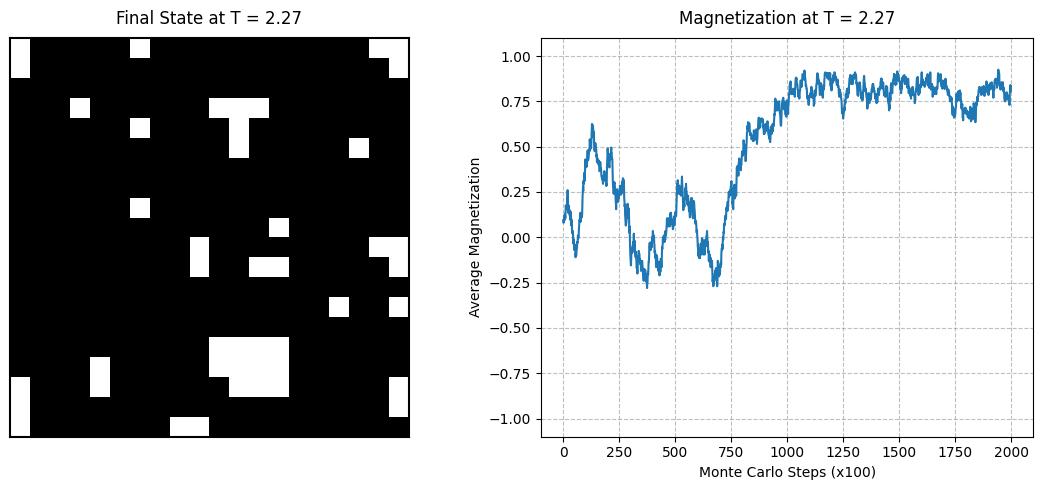

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. PARAMETER SISTEM & INISIALISASI (Memenuhi Aspek Akurasi Fisis)
# =========================================================================
N = 20                # Ukuran kisi dua dimensi (20x20)
MCS = 200000          # Total iterasi / langkah Monte Carlo
T = 2.27              # Suhu sistem (Suhu Kritis Tc ≈ 2.269)

# Inisialisasi Hot Start: Konfigurasi spin acak (+1 atau -1) untuk entropi maksimum
grid = np.random.choice([-1, 1], size=(N, N))
mag_history = []      # Array untuk menyimpan riwayat nilai magnetisasi rata-rata

# =========================================================================
# 2. ALGORITMA METROPOLIS (Memenuhi Aspek Efisiensi Komputasi)
# =========================================================================
# Optimalisasi dilakukan dengan hanya menghitung selisih energi lokal (Delta E)
# dari spin yang terpilih, bukan menghitung ulang energi total seluruh kisi.
for step in range(MCS):
    # Pemilihan koordinat kisi secara acak homogen
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)
    s = grid[i, j]

    # Kondisi Batas Periodik (Periodic Boundary Conditions) dengan operasi modulo (%)
    # Menghitung total spin dari 4 tetangga terdekat (Nearest Neighbors)
    tetangga = (grid[(i + 1) % N, j] +
                grid[(i - 1) % N, j] +
                grid[i, (j + 1) % N] +
                grid[i, (j - 1) % N])

    # Formulasi Matematis Selisih Energi Lokal (Delta E)
    delta_E = 2 * s * tetangga

    # Kriteria Penerimaan Metropolis (Metropolis Acceptance Criterion)
    if delta_E < 0:
        s *= -1  # Keadaan energi baru yang lebih rendah langsung diterima
    elif np.random.rand() < np.exp(-delta_E / T):
        s *= -1  # Keadaan energi lebih tinggi diterima berdasarkan probabilitas Boltzmann

    grid[i, j] = s  # Pembaruan keadaan spin pada matriks kisi

    # Pencatatan Magnetisasi Rata-rata setiap 100 langkah (Sampling Efisien)
    if step % 100 == 0:
        mag_history.append(np.sum(grid) / (N**2))

# =========================================================================
# 3. VISUALISASI DATA (SUDAH DIPERBAIKI DARI EROR INDENTASI)
# =========================================================================
# Penyelarasan Simetri (Symmetry Adjustment)
mag_plot = np.array(mag_history)
grid_plot = np.copy(grid)
if mag_plot[-1] < 0:
    mag_plot = -mag_plot
    grid_plot = -grid_plot

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Plot 1: Keadaan Akhir Kisi (Final State Grid)
axes[0].imshow(grid_plot, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f"Final State at T = {T:.2f}", fontsize=12, pad=10)
axes[0].set_xticks([])
axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Plot 2: Riwayat Magnetisasi Rata-rata (Magnetization Curve)
axes[1].plot(range(len(mag_plot)), mag_plot, color='tab:blue', linewidth=1.5)
axes[1].set_title(f"Magnetization at T = {T:.2f}", fontsize=12, pad=10)
axes[1].set_xlabel("Monte Carlo Steps (x100)", fontsize=10)
axes[1].set_ylabel("Average Magnetization", fontsize=10)
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.5, color='gray')

plt.tight_layout()
plt.show()